### Imports

In [29]:
import os
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import spearmanr, ttest_rel, zscore
from statsmodels.stats.multitest import multipletests

from sklearn.manifold import MDS
from scipy.spatial.distance import pdist, squareform


sys.path.insert(0, "/data/lea_schmitt/multiarrangement")

from rsatools import rdm_to_vector, visualize_rdm, build_similarity_matrix

### Stimuli definitions

In [30]:
ORDER = [
    # Letters with 3 variants (normal, large, rot90)
    "b_normal", "b_large", "b_normal_rot90",
    "d_normal", "d_large", "d_normal_rot90",
    "q_normal", "q_large", "q_normal_rot90",
    "p_normal", "p_large", "p_normal_rot90",
    # Letters with 5 variants (normal, large, flip_h, flip_v, rot90)
    "r_normal", "r_large", "r_normal_flip_h", "r_normal_flip_v", "r_normal_rot90",
    "a_normal", "a_large", "a_normal_flip_h", "a_normal_flip_v", "a_normal_rot90",
    "e_normal", "e_large", "e_normal_flip_h", "e_normal_flip_v", "e_normal_rot90",
    "f_normal", "f_large", "f_normal_flip_h", "f_normal_flip_v", "f_normal_rot90",
    "h_normal", "h_large", "h_normal_flip_h", "h_normal_flip_v", "h_normal_rot90",
    "k_normal", "k_large", "k_normal_flip_h", "k_normal_flip_v", "k_normal_rot90",
]


horizontal_pairs = [
    # reversible pairs
    ("reversible", "b↔d", "b_normal", "d_normal"),
    ("reversible", "b↔d", "b_large", "d_large"),
    ("reversible", "b↔d", "b_normal_rot90", "d_normal_rot90"),
    ("reversible", "p↔q", "p_normal", "q_normal"),
    ("reversible", "p↔q", "p_large", "q_large"),
    ("reversible", "p↔q", "p_normal_rot90", "q_normal_rot90"),
    # h-flip pairs
    ("non-reversible", "r↔r_flip_h", "r_normal", "r_normal_flip_h"),
    ("non-reversible", "a↔a_flip_h", "a_normal", "a_normal_flip_h"),
    ("non-reversible", "e↔e_flip_h", "e_normal", "e_normal_flip_h"),
    ("non-reversible", "f↔f_flip_h", "f_normal", "f_normal_flip_h"),
    ("non-reversible", "h↔h_flip_h", "h_normal", "h_normal_flip_h"),
    ("non-reversible", "k↔k_flip_h", "k_normal", "k_normal_flip_h"),
]


rev_letters     = ["b", "d", "p", "q"]
non_rev_letters = ["r", "a", "e", "f", "h", "k"]

condition_order = ["horizontal", "vertical", "90° rotation", "large"]
class_order     = ["reversible", "non-reversible"]

# Outlier detection results
OUTLIERS = pd.read_csv("results/behavior/outlier_detection_per_participant.csv")
OUTPUT_PATH_FIGS = "figures"
if not os.path.exists(OUTPUT_PATH_FIGS):
    os.makedirs(OUTPUT_PATH_FIGS)


### Helper Functions

In [31]:
def p_to_stars(p: float) -> str:
    """Map p-values to significance stars."""
    if pd.isna(p):
        return "n/a"
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "n.s."


def mean_ci(
    df: pd.DataFrame,
    condition: str,
    cls: str,
    value_col: str = "dissimilarity",
    condition_col: str = "condition",
    class_col: str = "letter_class",
) -> tuple[float, float]:
    """Return mean and 95% CI half-width for a condition x class subset."""
    vals = df.loc[
        (df[condition_col] == condition) & (df[class_col] == cls),
        value_col,
    ]
    if len(vals) < 2:
        return (vals.mean() if len(vals) else np.nan), 0.0
    return vals.mean(), 1.96 * vals.std() / np.sqrt(len(vals))


def pair_distance(rdm: np.ndarray, stim_to_idx: dict[str, int], stim_a: str, stim_b: str) -> float:
    """Return pairwise dissimilarity from an RDM by stimulus labels."""
    return float(rdm[stim_to_idx[stim_a], stim_to_idx[stim_b]])

#### Plot helper functions and definitions

In [32]:
class_order = ["reversible", "non-reversible"]

sns.set_theme(style="white")

# cmap for heatmaps of RDMs

cmap = sns.light_palette("#2e6b3a", as_cmap=True)

# Shared plotting style & statistics helpers 

PALETTE = {
    "reversible": "#2e6b3a",
    "non-reversible": "#a9c2ae",
}
PALETTE_SINGLE = "#6C9774"

FIGSIZE = (6.8, 6)

TITLE_FONTSIZE = 18
LABEL_FONTSIZE = 16
TICK_FONTSIZE = 14
LEGEND_FONTSIZE = 14
ANNOTATION_FONTSIZE = 14

BAR_WIDTH = 0.6
CAPSIZE = 0.10

def apply_axes_style(ax, xlabel="", ylabel="Mean Euclidean Distance"):
    """Consistent bar-plot styling: white background, top/right spines removed."""
    ax.set_facecolor("white")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(True)
    ax.spines["bottom"].set_visible(True)

    ax.tick_params(axis="x", labelsize=TICK_FONTSIZE)
    ax.tick_params(axis="y", labelsize=TICK_FONTSIZE)

    if xlabel:
        ax.set_xlabel(xlabel, fontsize=LABEL_FONTSIZE, labelpad=8)
    ax.set_ylabel(ylabel, fontsize=LABEL_FONTSIZE, labelpad=8)


def summary_with_ci(df, group_cols, value_col="dissimilarity"):
    """Mean / std / count / 95% CI half-width per group."""
    summary = df.groupby(group_cols, as_index=False)[value_col].agg(["mean", "std", "count"]).reset_index()
    if isinstance(summary.columns, pd.MultiIndex):
        summary.columns = [c[0] if c[1] == "" else c[1] for c in summary.columns]
    summary["ci"] = 1.96 * summary["std"] / np.sqrt(summary["count"])
    return summary


def paired_ttest(df, group_col, level_a, level_b, participant_col="participant", value_col="dissimilarity"):
    """Paired t-test between two levels of group_col, using participant-level means."""
    wide = (
        df.groupby([participant_col, group_col], as_index=False)[value_col]
        .mean()
        .pivot(index=participant_col, columns=group_col, values=value_col)
        .dropna()
    )
    if wide.shape[0] > 1 and level_a in wide.columns and level_b in wide.columns:
        t_stat, p_val = ttest_rel(wide[level_a], wide[level_b])
    else:
        t_stat, p_val = np.nan, np.nan
    return t_stat, p_val, wide.shape[0]


def holm_correct(pvals):
    """Holm-corrected p-values; returns [] for empty input."""
    if not pvals:
        return []
    _, p_holm, _, _ = multipletests(pvals, alpha=0.05, method="holm")
    return list(p_holm)


def draw_sig_bracket(ax, x_left, x_right, y_base, height, label, color="#1f2a1f", fontsize=None):
    """Draw a significance bracket between x_left/x_right with a centered label above it."""
    if fontsize is None:
        fontsize = ANNOTATION_FONTSIZE
    ax.plot([x_left, x_left, x_right, x_right], [y_base, y_base + height, y_base + height, y_base],
            lw=1.3, c=color)
    ax.text((x_left + x_right) / 2, y_base + height + 0.4 * height, label,
            ha="center", va="bottom", fontsize=fontsize, color=color)
    
def get_bracket_y(i_a, i_b):
    max_y = max(bar_tops.get(condition_order[i_a], 0),
                bar_tops.get(condition_order[i_b], 0)) + 0.03 * yrange
    for (k_a, k_b), y in bracket_heights.items():
        if k_a <= i_b and k_b >= i_a:
            max_y = max(max_y, y + step)
    return max_y


##### Importing RDMs 
Separately for excluded RDMs and included RDMs useing the Outlier detection done in outlier analysis

In [33]:
RDMs_excl = []
excluded_names = []
RDMs_incl = []
included_names = []


for participant in OUTLIERS["filename"].unique():
    participant_data = OUTLIERS[OUTLIERS["filename"] == participant]
    if participant_data["is_outlier"].any():
        excluded_names.append(participant)
        RDMs_excl.append(pd.read_csv(f"rdms/behavior/{participant}", index_col=0).values)
    else:
        included_names.append(participant)
        RDMs_incl.append(pd.read_csv(f"rdms/behavior/{participant}", index_col=0).values)

RDMs_excl 

[array([[0.        , 0.55836005, 0.8323031 , ..., 1.06931295, 0.55040648,
         0.96565786],
        [0.55836005, 0.        , 0.55939496, ..., 1.14019895, 0.95343494,
         1.17709359],
        [0.8323031 , 0.55939496, 0.        , ..., 1.00624763, 0.93499323,
         1.0852443 ],
        ...,
        [1.06931295, 1.14019895, 1.00624763, ..., 0.        , 1.04160056,
         0.79601543],
        [0.55040648, 0.95343494, 0.93499323, ..., 1.04160056, 0.        ,
         0.38827207],
        [0.96565786, 1.17709359, 1.0852443 , ..., 0.79601543, 0.38827207,
         0.        ]], shape=(42, 42)),
 array([[0.        , 0.2002207 , 1.1058485 , ..., 1.41005836, 1.35212417,
         0.94348915],
        [0.2002207 , 0.        , 1.27041656, ..., 1.6490982 , 1.63114867,
         0.59853821],
        [1.1058485 , 1.27041656, 0.        , ..., 0.86946636, 1.06660382,
         1.60079685],
        ...,
        [1.41005836, 1.6490982 , 0.86946636, ..., 0.        , 0.8710754 ,
         1.4302706

#### Participant Correlation RDM

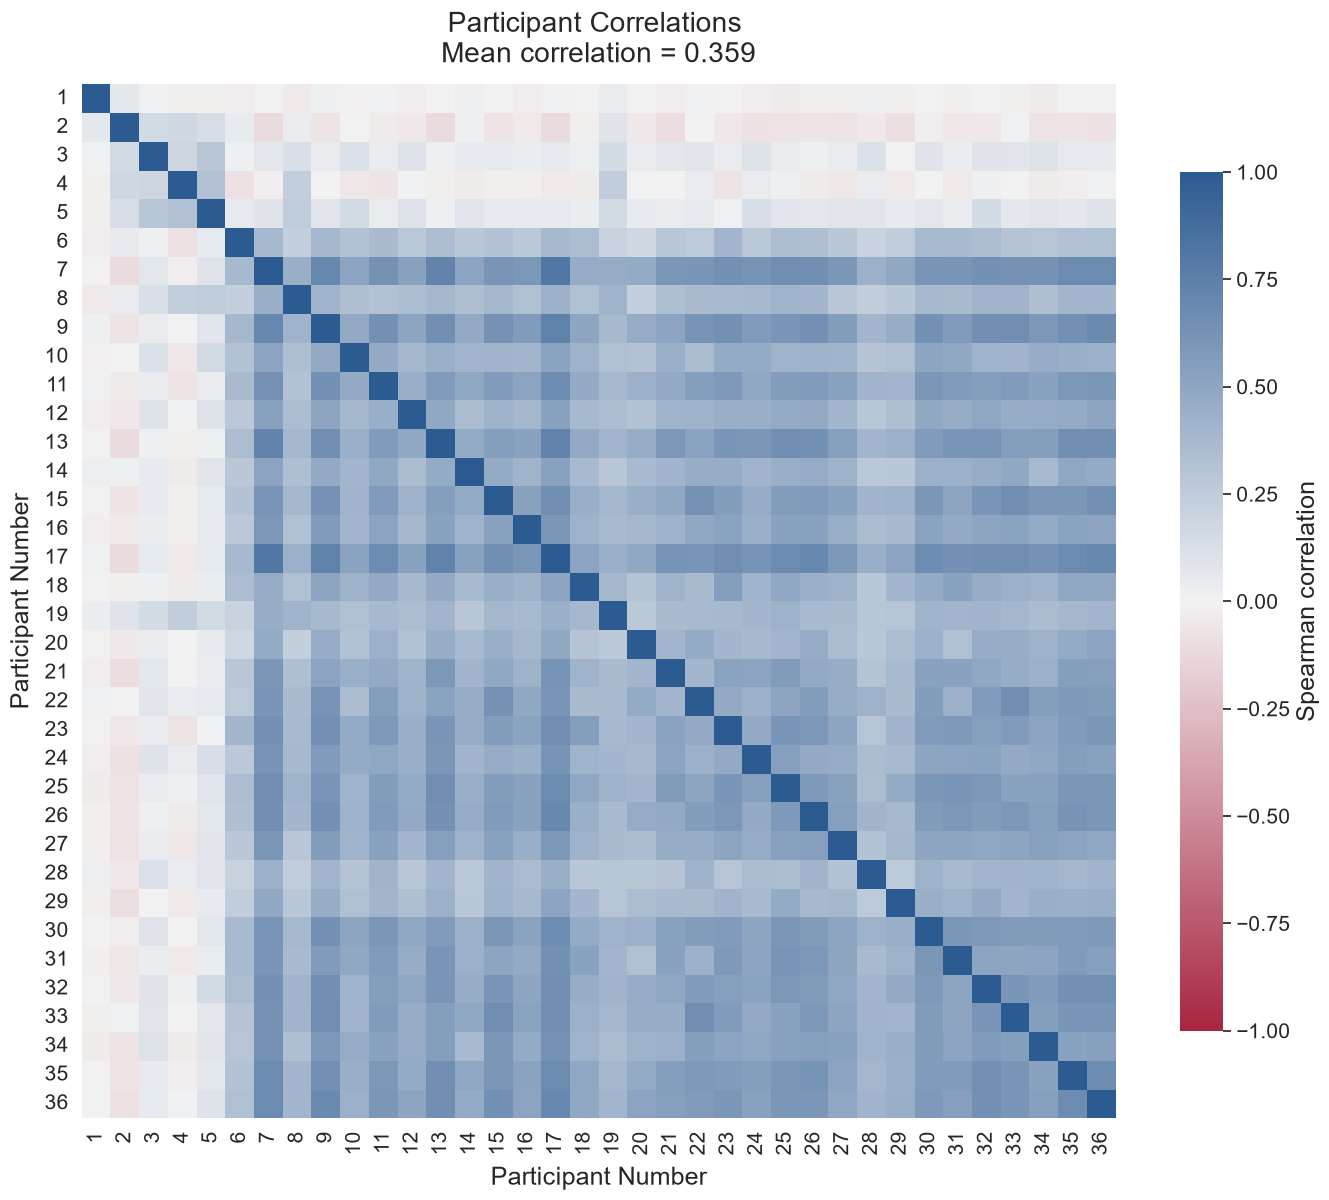

In [34]:
all_rdms = RDMs_excl + RDMs_incl 
participant_labels = [str(i + 1) for i in range(len(all_rdms))]

# Vectorize upper triangle (excluding diagonal) for each RDM
tri_idx = np.triu_indices_from(all_rdms[0], k=1)
rdm_vectors = np.array([rdm[tri_idx] for rdm in all_rdms])

# Participant-by-participant correlation matrix
corr_matrix = np.corrcoef(rdm_vectors)

# Mean correlation excluding the diagonal
off_diag = corr_matrix[np.triu_indices_from(corr_matrix, k=1)]
mean_corr = off_diag.mean()
std_corr = off_diag.std()

# Darker, low-saturation diverging colormap: pink -> white -> blue
pastel_pink_blue = sns.diverging_palette(
    365, 250, s=80, l=38, center="light", as_cmap=True
)

fig, ax = plt.subplots(figsize=(14, 12))
hm = sns.heatmap(
    corr_matrix,
    cmap=pastel_pink_blue,
    vmin=-1,
    vmax=1,
    xticklabels=participant_labels,
    yticklabels=participant_labels,
    square=True,
    cbar_kws={"shrink": 0.8, "label": "Spearman correlation"},
    ax=ax
)

# Set all non-title text to 14
ax.set_xlabel("Participant Number", fontsize=18, labelpad=8)
ax.set_ylabel("Participant Number", fontsize=18, labelpad=8)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center", fontsize=15)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=15)

# Title at 18
ax.set_title(
    f"Participant Correlations \nMean correlation = {mean_corr:.3f}",
    pad=16,
    fontsize=20,
)

# Colorbar font sizes
cbar = hm.collections[0].colorbar
cbar.set_label("Spearman correlation", fontsize=18)
cbar.ax.tick_params(labelsize=15)

plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_PATH_FIGS, "participant_rdm_correlation_matrix.png"),
    dpi=600,
    bbox_inches="tight",
)
plt.show()

#### MDS Plots
First on Participant level, than on stimulus level

c:\Users\jlu-su\PycharmProjects\Spezialisierungsmodul\.venv\Lib\site-packages\sklearn\manifold\_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
c:\Users\jlu-su\PycharmProjects\Spezialisierungsmodul\.venv\Lib\site-packages\sklearn\manifold\_mds.py:752: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


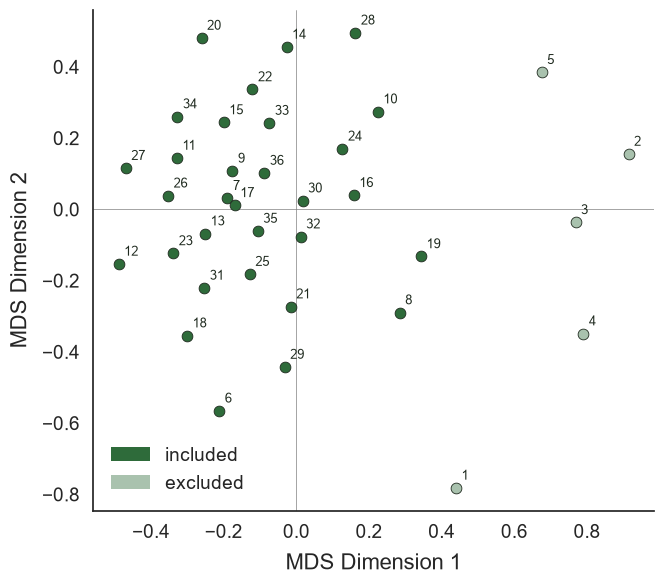

c:\Users\jlu-su\PycharmProjects\Spezialisierungsmodul\.venv\Lib\site-packages\sklearn\manifold\_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
c:\Users\jlu-su\PycharmProjects\Spezialisierungsmodul\.venv\Lib\site-packages\sklearn\manifold\_mds.py:752: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


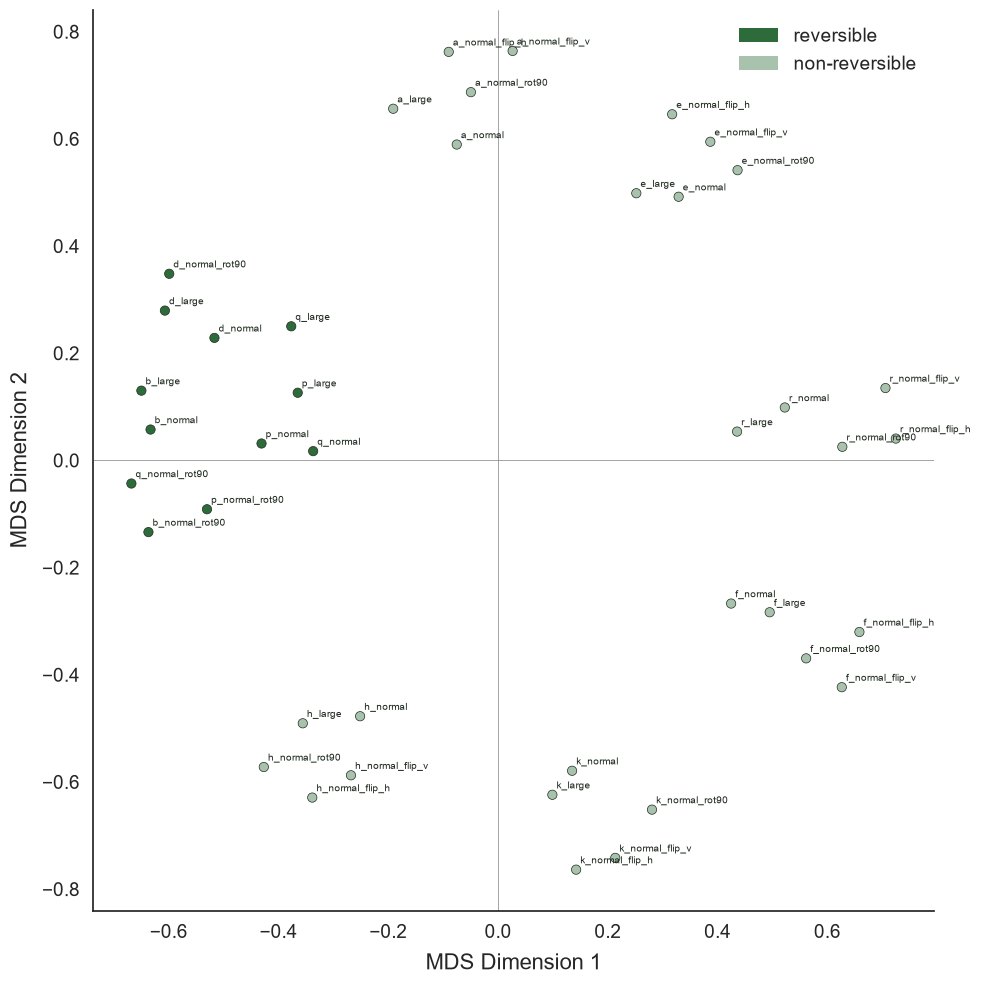

In [35]:
n_excl = len(RDMs_excl)

# ---------------------------------------------------------------
# Participant-level MDS
# ---------------------------------------------------------------
rdm_vectors = np.array([rdm[np.triu_indices_from(rdm, k=1)] for rdm in all_rdms])
participant_rdm = squareform(pdist(rdm_vectors, metric="correlation"))

mds_participants = MDS(n_components=2, dissimilarity="precomputed", random_state=42, n_init=10)
participant_coords = mds_participants.fit_transform(participant_rdm)

participant_labels = [str(i + 1) for i in range(len(all_rdms))]
participant_status = ["excluded"] * n_excl + ["included"] * (len(all_rdms) - n_excl)
participant_colors = {"included": PALETTE["reversible"], "excluded": PALETTE["non-reversible"]}

fig, ax = plt.subplots(figsize=FIGSIZE, facecolor="white")

for status in ["included", "excluded"]:
    mask = [s == status for s in participant_status]
    ax.scatter(
        participant_coords[mask, 0], participant_coords[mask, 1],
        s=60, color=participant_colors[status], edgecolor="#1f2a1f",
        linewidth=0.6, label=status, zorder=3,
    )

# Participant-level MDS — Label-Block ersetzen:
for x, y, label in zip(participant_coords[:, 0], participant_coords[:, 1], participant_labels):
    ax.annotate(label, (x, y), xytext=(4, 4), textcoords="offset points",
                fontsize=9, ha="left", va="bottom", color="#1f2a1f", zorder=4)

apply_axes_style(ax, xlabel="MDS Dimension 1", ylabel="MDS Dimension 2")
ax.axhline(0, color="grey", linewidth=0.5, zorder=1)
ax.axvline(0, color="grey", linewidth=0.5, zorder=1)

legend_handles = [
    Patch(facecolor=participant_colors["included"], edgecolor="none", label="included"),
    Patch(facecolor=participant_colors["excluded"], edgecolor="none", label="excluded"),
]
ax.legend(handles=legend_handles, title="", loc="best", fontsize=LEGEND_FONTSIZE, frameon=False)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH_FIGS, "mds_participants.png"), dpi=400, bbox_inches="tight")
plt.show()

# ---------------------------------------------------------------
# Stimulus-level MDS
# ---------------------------------------------------------------
stimulus_rdm = np.mean(all_rdms, axis=0)
stimulus_rdm = (stimulus_rdm + stimulus_rdm.T) / 2
np.fill_diagonal(stimulus_rdm, 0)

mds_stimuli = MDS(n_components=2, dissimilarity="precomputed", random_state=42, n_init=10)
stimulus_coords = mds_stimuli.fit_transform(stimulus_rdm)

stimulus_letters = [s.split("_")[0] for s in ORDER]
stimulus_colors = [
    PALETTE["reversible"] if letter in rev_letters else PALETTE["non-reversible"]
    for letter in stimulus_letters
]

fig, ax = plt.subplots(figsize=(10, 10), facecolor="white")

ax.scatter(
    stimulus_coords[:, 0], stimulus_coords[:, 1],
    s=45, color=stimulus_colors, edgecolor="#1f2a1f", linewidth=0.5, zorder=3,
)

for x, y, label in zip(stimulus_coords[:, 0], stimulus_coords[:, 1], ORDER):
    ax.annotate(label, (x, y), xytext=(3, 3), textcoords="offset points",
                fontsize=7.5, ha="left", va="bottom", color="#1f2a1f", zorder=4)

apply_axes_style(ax, xlabel="MDS Dimension 1", ylabel="MDS Dimension 2")
ax.axhline(0, color="grey", linewidth=0.5, zorder=1)
ax.axvline(0, color="grey", linewidth=0.5, zorder=1)

legend_handles = [
    Patch(facecolor=PALETTE["reversible"], edgecolor="none", label="reversible"),
    Patch(facecolor=PALETTE["non-reversible"], edgecolor="none", label="non-reversible"),
]
ax.legend(handles=legend_handles, title="", loc="best", fontsize=LEGEND_FONTSIZE, frameon=False)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH_FIGS, "mds_stimuli.png"), dpi=400, bbox_inches="tight")
plt.show()

#### RDMs of excluded participants

[label sizing] n_labels=42, fontsize=11pt -> panel size 8.3in


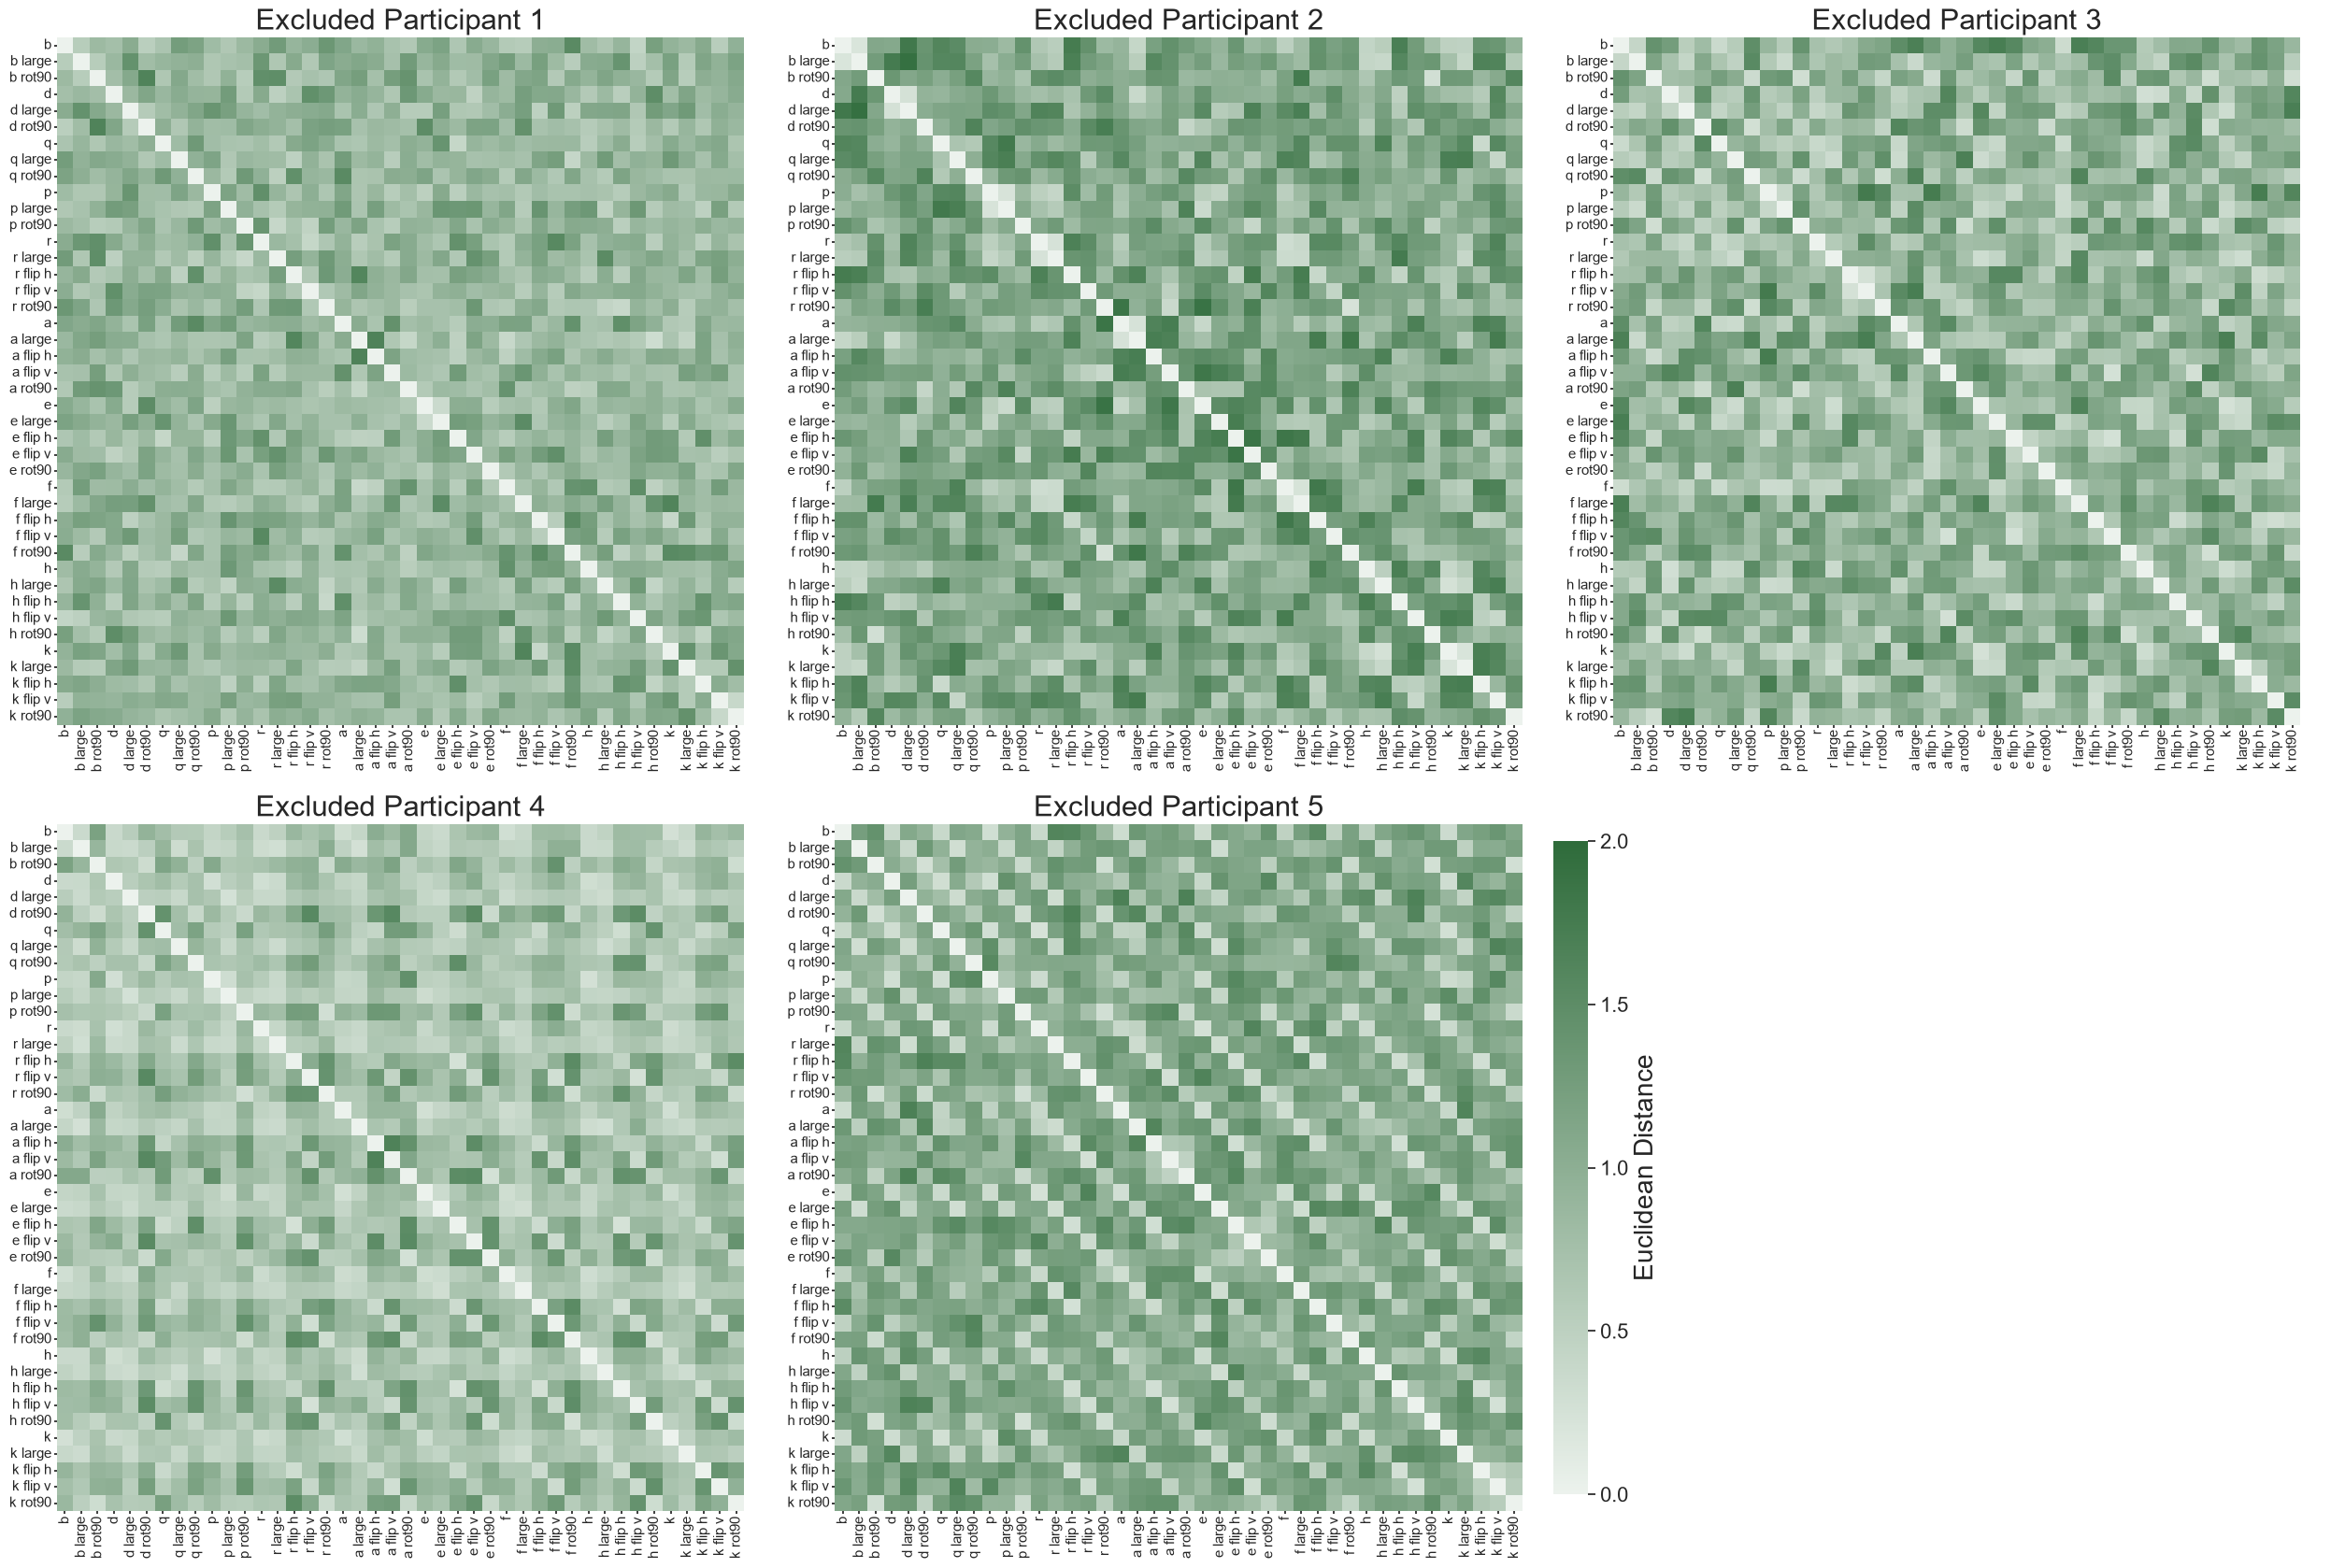

In [36]:
if len(RDMs_excl) > 0:
    vmin = min(np.min(rdm) for rdm in RDMs_excl)
    vmax = max(np.max(rdm) for rdm in RDMs_excl)

    clean_labels = [
        " ".join(lbl.replace("_", " ").replace("normal", "").split())
        for lbl in ORDER
    ]
    n_labels = len(clean_labels)

    n_labels             = len(clean_labels)
    TARGET_FONTSIZE      = 11
    LINE_SPACING_FACTOR  = 1.1
    USABLE_FRACTION      = 0.85
    label_fontsize       = TARGET_FONTSIZE
    required_heatmap_in  = (label_fontsize / 72) * LINE_SPACING_FACTOR * n_labels
    panel_size_in        = max(5.0, required_heatmap_in / USABLE_FRACTION)

    print(f"[label sizing] n_labels={n_labels}, fontsize={label_fontsize}pt -> panel size {panel_size_in:.1f}in")

    cmap_excl = sns.light_palette("#2e6b3a", as_cmap=True)
    n_cols, n_rows = 3, 2

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(panel_size_in * n_cols, panel_size_in * n_rows),
        sharex=False, sharey=False, squeeze=False, constrained_layout=True,
    )
    fig.set_constrained_layout_pads(w_pad=0.01, h_pad=0.01, wspace=0.01, hspace=0.03)

    panel_order = [0, 1, 2, 3, 4]
    axes_flat = axes.ravel()
    last_hm = last_ax = None

    for i, rdm_excl in enumerate(RDMs_excl):
        if i >= len(panel_order):
            break
        ax = axes_flat[panel_order[i]]
        hm = sns.heatmap(
            rdm_excl, ax=ax, cmap=cmap_excl, vmin=vmin, vmax=2,
            cbar=False, square=True,
            xticklabels=clean_labels, yticklabels=clean_labels,
        )
        last_hm, last_ax = hm, ax
        ax.set_title(f"Excluded Participant {i + 1}", fontsize=22, pad=6)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center", va="top", fontsize=label_fontsize)
        ax.tick_params(axis="x", labelbottom=True, bottom=True, length=2, pad=2)
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=label_fontsize)
        ax.tick_params(axis="y", left=True, labelleft=True, length=2, pad=2)

    used_idx = set(panel_order[: min(len(RDMs_excl), len(panel_order))])
    for j, ax in enumerate(axes_flat):
        if j not in used_idx:
            ax.axis("off")

    fig.canvas.draw()
    pos = last_ax.get_position()
    cbar_ax = fig.add_axes([pos.x1 + 0.012, pos.y0 + pos.height * 0.025, 0.015, pos.height * 0.95])
    cbar = fig.colorbar(last_hm.collections[0], cax=cbar_ax)
    cbar.outline.set_visible(False)
    cbar.set_label("Euclidean Distance", fontsize=20)
    cbar.set_ticks([0, 0.5, 1, 1.5, 2])
    cbar.ax.tick_params(labelsize=16)

    plt.savefig(
        os.path.join(OUTPUT_PATH_FIGS, "excluded_participants_rdms_grid.png"),
        dpi=400, bbox_inches="tight",
    )
    plt.show()

### Included participants

#### RDMs for included paricipants

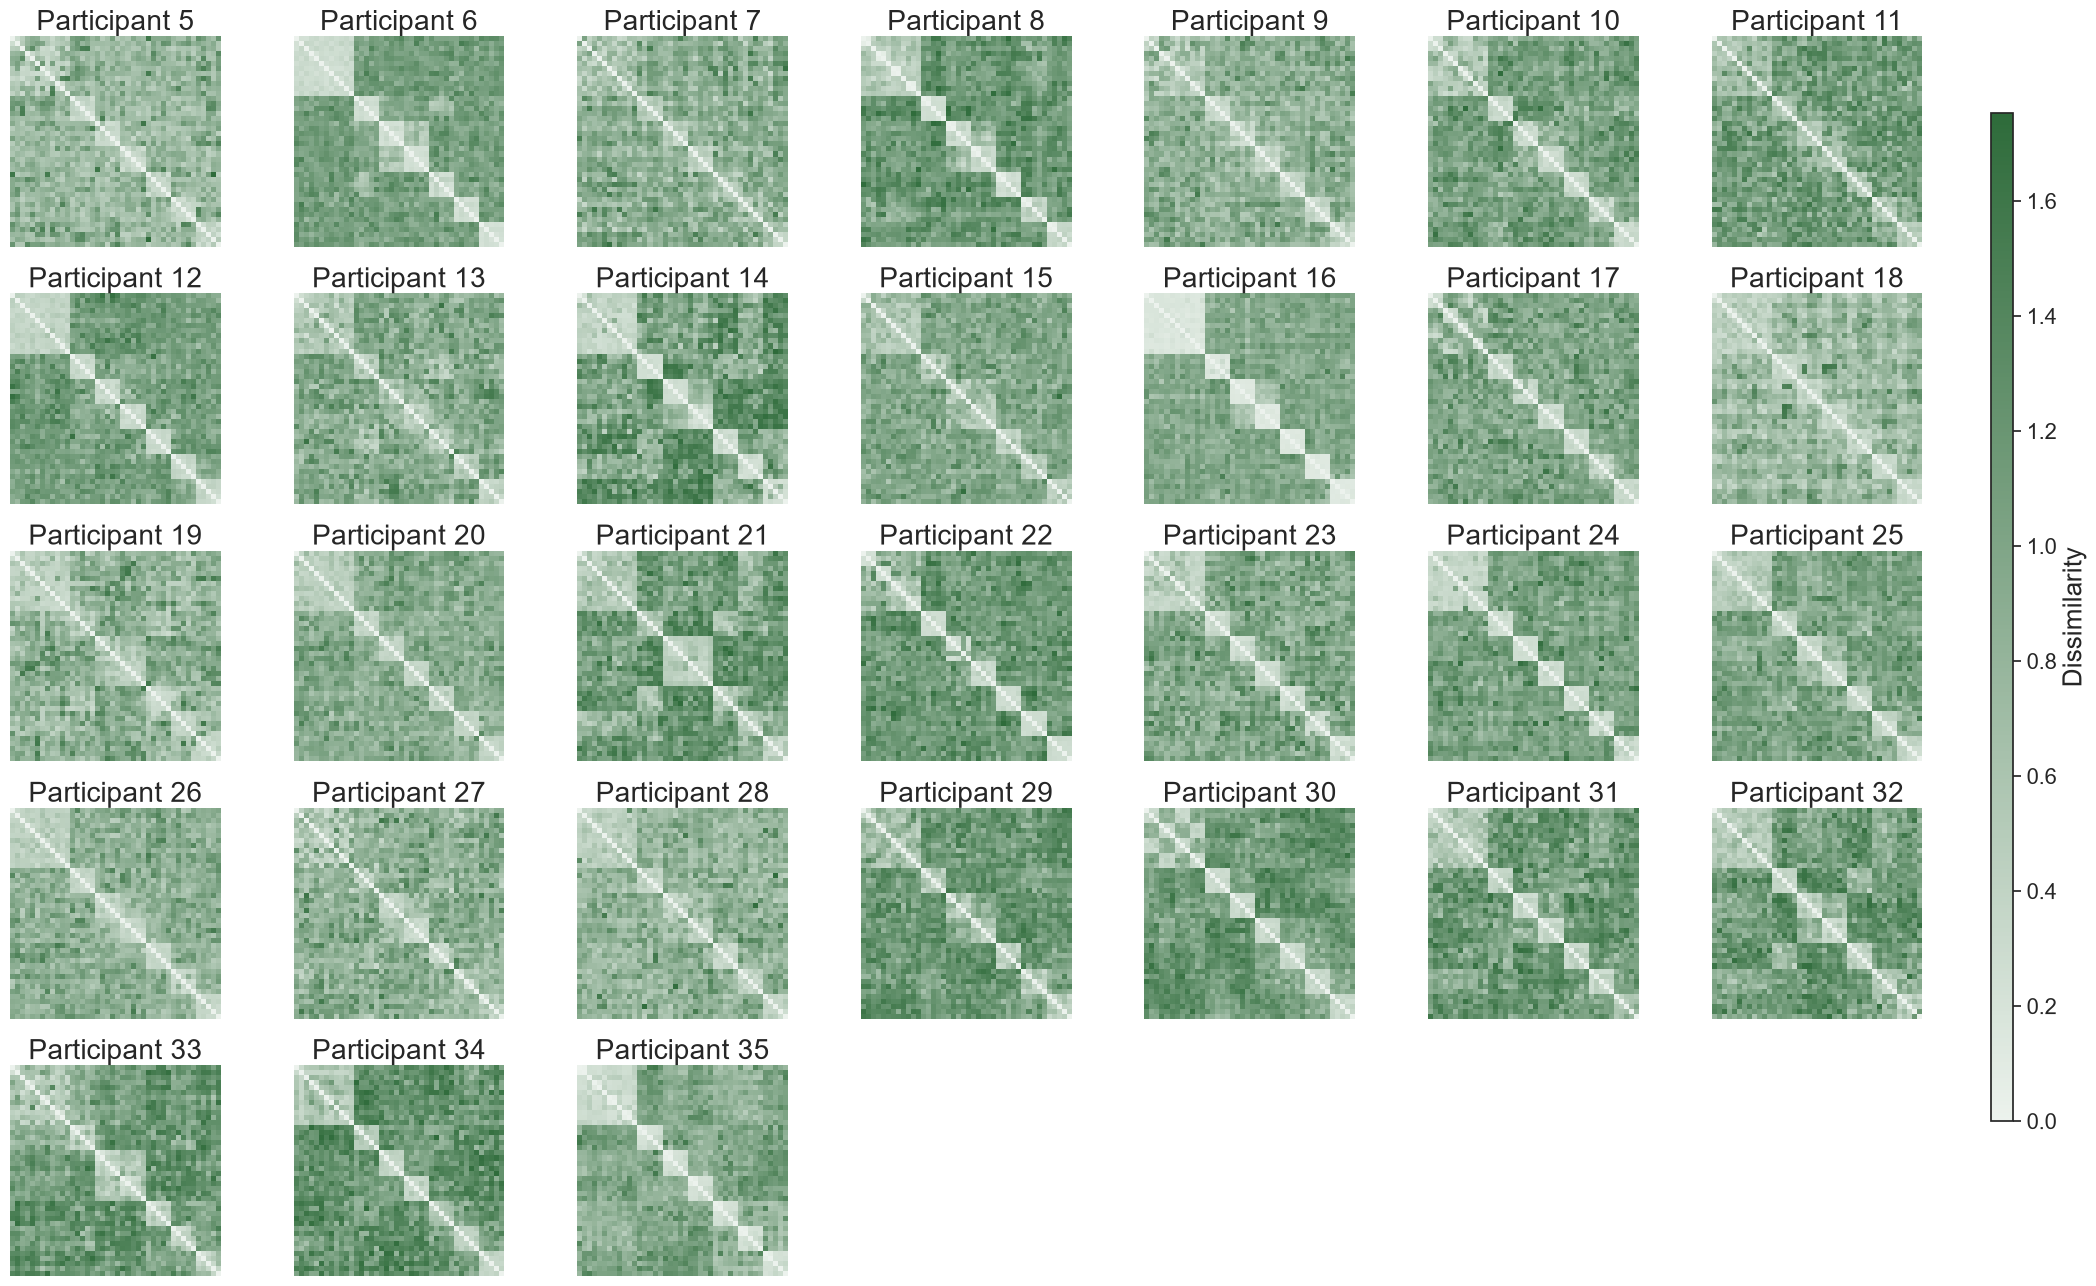

In [37]:
# Big grid plot of all participant RDMs (all participants, 8 columns)
n_rdms = len(RDMs_incl)
n_cols = 7
n_rows = int(np.ceil(n_rdms / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(3.2 * n_cols, 3.1 * n_rows),
    sharex=True,
    sharey=True,
    squeeze=False,
)
axes = np.array(axes).reshape(n_rows, n_cols)

last_hm = None
for i, ax in enumerate(axes.flat):
    if i < n_rdms:
        hm = sns.heatmap(
            RDMs_incl[i],
            ax=ax,
            cmap=cmap,
            vmin=0,
            vmax=np.max(RDMs_incl),
            cbar=False,
            square=True,
            xticklabels=False,
            yticklabels=False,
        )
        last_hm = hm
        ax.set_title(f"Participant {i + 5}", fontsize=20, pad=4)
        ax.tick_params(left=False, bottom=False)
    else:
        ax.axis("off")

# Tighter left/right margins, more breathing room on top/bottom
fig.subplots_adjust(left=0.015, right=0.90, top=0.88, bottom=0.08, wspace=0.01, hspace=0.22)

# One shared colorbar in a smaller dedicated axis on the right (no overlap)
if last_hm is not None:
    cbar_ax = fig.add_axes([0.915, 0.18, 0.010, 0.65])
    cbar = fig.colorbar(last_hm.collections[0], cax=cbar_ax)
    cbar.ax.tick_params(labelsize=16)
    cbar.set_label("Dissimilarity", fontsize=19)

fig.savefig(
    os.path.join(
        OUTPUT_PATH_FIGS,
        "included_participants_rdms_grid.png",
    ),
    dpi=400,
    bbox_inches="tight",
)
plt.show()

#### Mean RDM

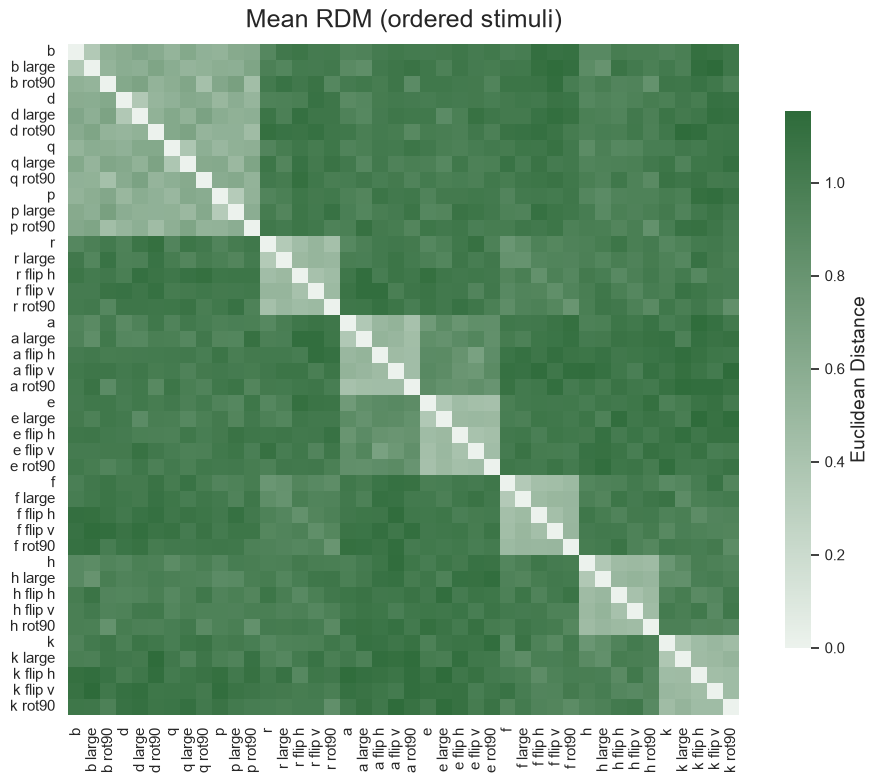

In [38]:
# Match the green used in the later bar plots
mean_rdm = pd.read_csv("rdms/behavior/mean/mean_behavior_rdm.csv", index_col=0)

fig, ax = plt.subplots(figsize=(10, 8))
hm = sns.heatmap(
    mean_rdm,
    cmap=cmap,
    xticklabels=clean_labels,
    yticklabels=clean_labels,
    square=True,
    cbar_kws={"shrink": 0.8},
    ax=ax
)

ax.set_title("Mean RDM (ordered stimuli)", pad=12, fontsize=18)
ax.set_xlabel("")
ax.set_ylabel("")

# Make labels readable
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center", fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=11)

cbar = hm.collections[0].colorbar
cbar.set_label("Euclidean Distance", fontsize=14)
cbar.ax.tick_params(labelsize=11)

plt.tight_layout()
plt.savefig(
    os.path.join(
        OUTPUT_PATH_FIGS,
        "mean_rdm_ordered_stimuli.png",
    ),
    dpi=600,
    bbox_inches="tight",
)
plt.show()

#### Statistics and DataFrame

In [ ]:
# suffix used for the *within-letter* transformed stimulus in each condition
condition_suffix = {
    "horizontal":   "_normal_flip_h",
    "vertical":     "_normal_flip_v",
    "90° rotation": "_normal_rot90",
    "large":        "_large",
}

# mirror-equivalent letter pairs for reversible horizontal/vertical
reversible_mirror_pairs = {
    "horizontal": [("b", "d"), ("p", "q")],
    "vertical":   [("b", "p"), ("d", "q")],
}

stim_to_idx = {stim: i for i, stim in enumerate(ORDER)}


def get_pair_value(rdm, stim_a, stim_b):
    """Return dissimilarity between two stimuli if both exist in this RDM's ordering."""
    if stim_a in stim_to_idx and stim_b in stim_to_idx:
        return pair_distance(rdm, stim_to_idx, stim_a, stim_b)
    return np.nan


def extract_reversible(rdm, participant):
    rows = []
    for cond in condition_order:
        if cond in reversible_mirror_pairs:
            # single _normal vs _normal comparison per pair, averaged across the 2 pairs
            vals = [
                get_pair_value(rdm, f"{a}_normal", f"{b}_normal")
                for a, b in reversible_mirror_pairs[cond]
            ]
        else:
            # within-letter normal vs transformed, averaged across the 4 reversible letters
            suffix = condition_suffix[cond]
            vals = [
                get_pair_value(rdm, f"{letter}_normal", f"{letter}{suffix}")
                for letter in rev_letters
            ]
        vals = [v for v in vals if pd.notna(v)]
        rows.append({
            "participant": participant,
            "letter_class": "reversible",
            "condition": cond,
            "dissimilarity": np.mean(vals) if vals else np.nan,
        })
    return rows


def extract_nonrev(rdm, participant):
    rows = []
    for cond in condition_order:
        suffix = condition_suffix[cond]
        vals = [
            get_pair_value(rdm, f"{letter}_normal", f"{letter}{suffix}")
            for letter in non_rev_letters
        ]
        vals = [v for v in vals if pd.notna(v)]
        rows.append({
            "participant": participant,
            "letter_class": "non-reversible",
            "condition": cond,
            "dissimilarity": np.mean(vals) if vals else np.nan,
        })
    return rows


combo_rows = []
for participant, rdm in enumerate(RDMs_incl, start=1):
    combo_rows.extend(extract_reversible(rdm, participant))
    combo_rows.extend(extract_nonrev(rdm, participant))

combo_df = pd.DataFrame(combo_rows)
combo_df["condition"] = pd.Categorical(combo_df["condition"], categories=condition_order, ordered=True)
combo_df["letter_class"] = pd.Categorical(combo_df["letter_class"], categories=class_order, ordered=True)

print(f"Built combo_df: {len(combo_df)} rows "
      f"({combo_df['participant'].nunique()} participants x "
      f"{len(class_order)} classes x {len(condition_order)} conditions).")

# sanity check: should be participants x 2 x 4 rows, no unexpected NaNs
n_expected = combo_df["participant"].nunique() * len(class_order) * len(condition_order)
assert len(combo_df) == n_expected, "Unexpected row count — check stimulus labels in ORDER."
n_missing = combo_df["dissimilarity"].isna().sum()
if n_missing:
    print(f"Warning: {n_missing} missing dissimilarity values — check ORDER/labels for gaps.")

Built combo_df: 248 rows (31 participants x 2 classes x 4 conditions).


### Information on statistics

**Inferential statistics** (the 2×4 repeated-measures ANOVA with Greenhouse–Geisser correction, and the Holm-corrected post-hoc comparisons reported in the paper) were computed in R
(`statistics_behavior.R`), using `afex::aov_ez()` and `emmeans()`. That script is the authoritative source for all F-, t-, and p-values cited in the text.

**Significance annotations in the plots below** are *not* recomputed from the ANOVA model.
For simplicity, they are added using a separate paired t-test on the same participant-level means, with Holm correction applied within each figure.

Both approaches were compared value-by-value against the R output and found to agree (same significance pattern, comparable effect sizes) for every contrast shown here.

#### Bar Plot: Reversible vs Non-Reversible

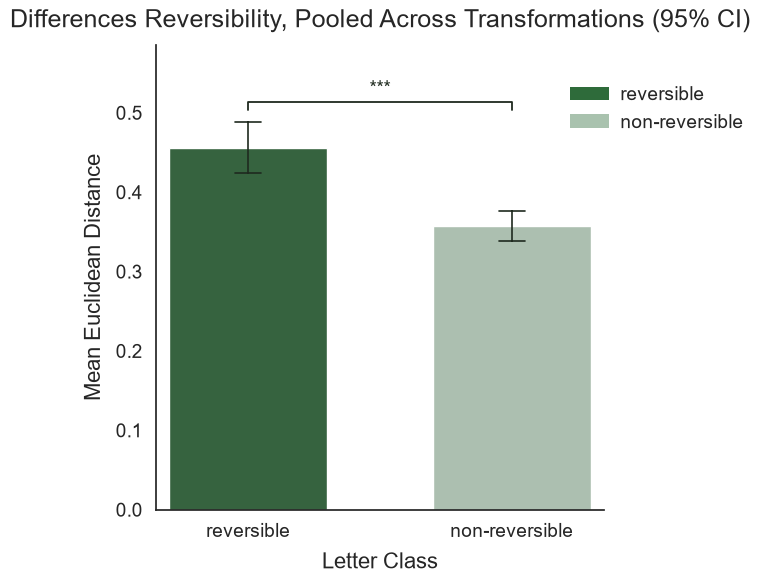

In [40]:
summary_by_class = summary_with_ci(combo_df, "letter_class")

fig, ax = plt.subplots(figsize=(7.5, 6), facecolor="white")

sns.barplot(
    data=combo_df,
    x="letter_class", y="dissimilarity", hue="letter_class",
    order=class_order, hue_order=class_order, palette=PALETTE,
    estimator=np.mean, errorbar=("ci", 95),
    width=BAR_WIDTH, capsize=CAPSIZE,
    err_kws={"color": "#1f2a1f", "linewidth": 1.2},
    ax=ax, dodge=False, legend=False,
)

apply_axes_style(ax, xlabel="Letter Class")
ax.set_xlim(-0.35, 1.35)
ax.set_title("Differences Reversibility, Pooled Across Transformations (95% CI)",
             fontsize=TITLE_FONTSIZE, pad=13)

legend_handles = [
    Patch(facecolor=PALETTE["reversible"], edgecolor="none", label="reversible"),
    Patch(facecolor=PALETTE["non-reversible"], edgecolor="none", label="non-reversible"),
]
ax.legend(handles=legend_handles, title="", loc="upper right",
          bbox_to_anchor=(1.35, 0.95), fontsize=LEGEND_FONTSIZE,
          frameon=False, handletextpad=0.6)

# Significance annotation (paired t-test, pooled across all conditions)
_, p_val, _ = paired_ttest(combo_df, "letter_class", "reversible", "non-reversible")
label = p_to_stars(p_val)

ymin, ymax = ax.get_ylim()
yrange = ymax - ymin if ymax > ymin else 1.0
y_base = summary_by_class["mean"].max() + summary_by_class["ci"].max() + 0.03 * yrange
h = 0.02 * yrange
draw_sig_bracket(ax, 0, 1, y_base, h, label)
ax.set_ylim(ymin, ymax + 0.14 * yrange)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH_FIGS, "reversible_vs_nonreversible_pooled.png"), dpi=600, bbox_inches="tight")
plt.show()


#### Bar Plot: Dissimilarity Across Transformations 

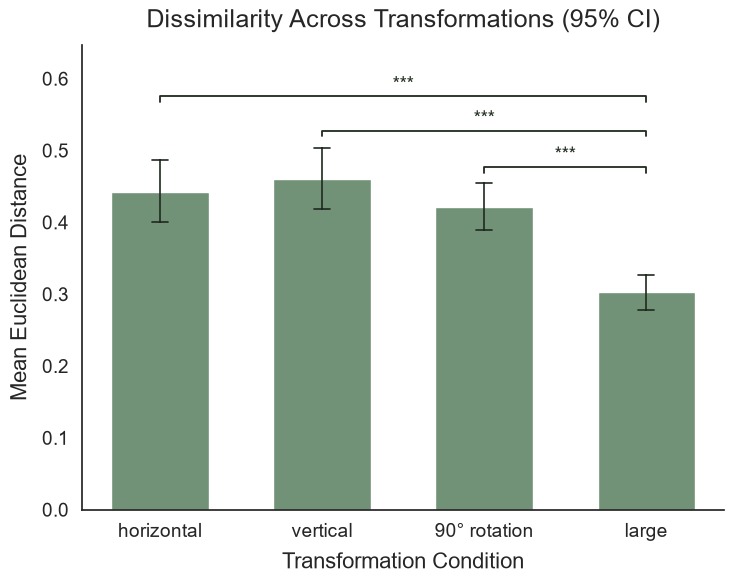

In [41]:
condition_summary = summary_with_ci(combo_df, "condition")

# Pairwise comparisons: each non-large condition vs "large"
non_large_conditions = [c for c in condition_order if c != "large"]
pairwise_results = []
for cond_a in non_large_conditions:
    t_stat, p_raw, n = paired_ttest(combo_df, "condition", cond_a, "large")
    pairwise_results.append({
        "Comparison": f"{cond_a} vs large",
        "cond_a": cond_a, "cond_b": "large",
        "t_stat": t_stat, "p_raw": p_raw, "n": n,
    })

for r, p_holm in zip(pairwise_results, holm_correct([r["p_raw"] for r in pairwise_results])):
    r["p_holm"] = p_holm
    r["label"] = p_to_stars(p_holm)

fig, ax = plt.subplots(figsize=(7.5, 6), facecolor="white")

sns.barplot(
    data=combo_df,
    x="condition", y="dissimilarity",
    order=condition_order, color=PALETTE_SINGLE,
    estimator=np.mean, errorbar=("ci", 95),
    width=BAR_WIDTH, capsize=CAPSIZE,
    err_kws={"color": "#1f2a1f", "linewidth": 1.2},
    ax=ax,
)

apply_axes_style(ax, xlabel="Transformation Condition")
ax.set_title("Dissimilarity Across Transformations (95% CI)", fontsize=TITLE_FONTSIZE, pad=13)

# Significance brackets (stacked to avoid overlap)
sig_pairs = sorted(
    [r for r in pairwise_results if r["label"] != "n.s."],
    key=lambda r: abs(condition_order.index(r["cond_b"]) - condition_order.index(r["cond_a"])),
)
bar_tops = {row["condition"]: row["mean"] + row["ci"] for _, row in condition_summary.iterrows()}
ymin, ymax = ax.get_ylim()
yrange = (ymax - ymin) or 1.0
step = 0.09 * yrange
bracket_heights = {}

h = 0.015 * yrange
for r in sig_pairs:
    i_a, i_b = condition_order.index(r["cond_a"]), condition_order.index(r["cond_b"])
    y_base = get_bracket_y(i_a, i_b)
    bracket_heights[(i_a, i_b)] = y_base
    draw_sig_bracket(ax, i_a, i_b, y_base, h, r["label"])

if bracket_heights:
    max_bracket = max(bracket_heights.values()) + step + 0.02 * yrange
    ax.set_ylim(ymin, max(ymax, max_bracket) + 0.04 * yrange)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH_FIGS, "conditions_collapsed.png"), dpi=600, bbox_inches="tight")
plt.show()


#### Bar-Plot: Reversible vs Non-Reversible Letters Across Transformations 

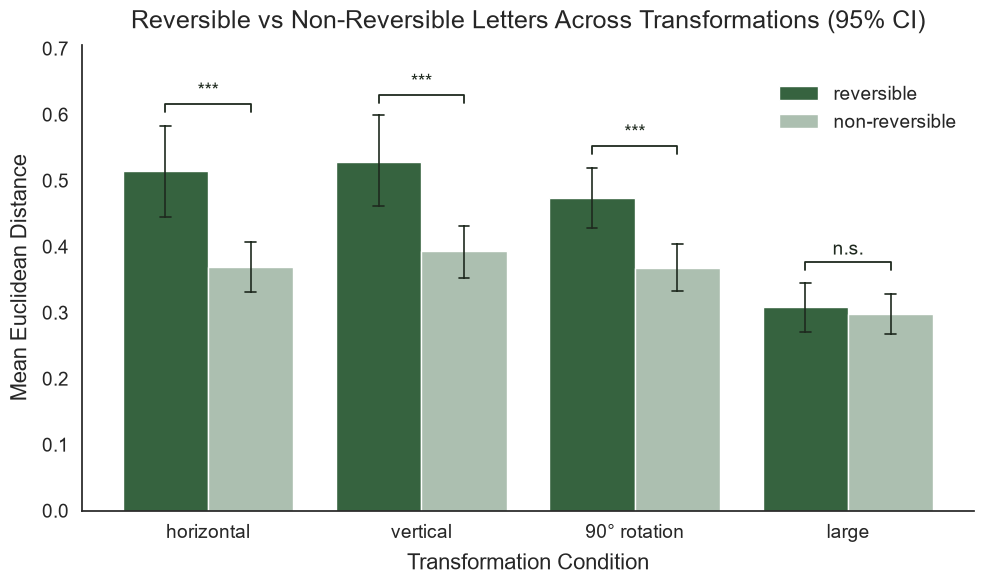

In [43]:
fig, ax = plt.subplots(figsize=(10, 6), facecolor="white")

sns.barplot(
    data=combo_df,
    x="condition", y="dissimilarity", hue="letter_class",
    order=condition_order, hue_order=class_order, palette=PALETTE,
    estimator=np.mean, errorbar=("ci", 95),
    width=0.8, capsize=0.1,
    err_kws={"color": "#1f2a1f", "linewidth": 1.2},
    ax=ax, dodge=True,
)

apply_axes_style(ax, xlabel="Transformation Condition")
ax.set_title(
    "Reversible vs Non-Reversible Letters Across Transformations (95% CI)",
    pad=12, fontsize=TITLE_FONTSIZE,
)
ax.legend(title="", loc="upper right", bbox_to_anchor=(1.0, 0.95),
          fontsize=LEGEND_FONTSIZE, frameon=False)

# Paired t-tests per condition (reversible vs non-reversible), Holm-corrected
results = []
for cond in condition_order:
    sub = combo_df[combo_df["condition"] == cond]
    t_stat, p_raw, n_pairs = paired_ttest(sub, "letter_class", "reversible", "non-reversible")
    results.append({
        "condition": cond, "n_pairs": n_pairs,
        "t_stat": t_stat, "p_raw": p_raw if pd.notna(p_raw) else 1.0,
    })

for r, p_holm in zip(results, holm_correct([r["p_raw"] for r in results])):
    r["p_holm"] = p_holm
    r["label"] = p_to_stars(p_holm)

sig_by_cond = {r["condition"]: r for r in results}
ymin, ymax = ax.get_ylim()
yrange = (ymax - ymin) or 1.0

for i, cond in enumerate(condition_order):
    mean_rev, ci_rev = mean_ci(combo_df, cond, "reversible")
    mean_non, ci_non = mean_ci(combo_df, cond, "non-reversible")
    if pd.isna(mean_rev) or pd.isna(mean_non):
        continue
    y_base = max(mean_rev + ci_rev, mean_non + ci_non) + 0.03 * yrange
    h = 0.02 * yrange
    draw_sig_bracket(ax, i - 0.2, i + 0.2, y_base, h, sig_by_cond[cond]["label"])

ax.set_ylim(ymin, ymax + 0.12 * yrange)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH_FIGS, "reversible_vs_nonreversible_conditions.png"), dpi=600)
plt.show()